<h1 style="text-align: center;">Pharma Sales Data Clustering

## 0. Libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## 1. Read CSVs 

In [2]:
salesdaily=pd.read_csv('~/Portfolio/salesdaily_clean.csv' , sep=",")
countrycodes=pd.read_csv('~/Portfolio/countrycodes.csv' , sep=";")

In [3]:
salesdaily.info()
salesdaily.columns = salesdaily.columns.str.replace('\u00A0', '', regex=True) # remove non-breaking spaces
print(salesdaily.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 35 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            2106 non-null   object 
 1   M01AB           2106 non-null   float64
 2   M01AE           2106 non-null   float64
 3   N02BA           2106 non-null   float64
 4   N02BE           2106 non-null   float64
 5   N05B            2106 non-null   float64
 6   N05C            2106 non-null   float64
 7   R03HU           2106 non-null   float64
 8   R06AE           2106 non-null   float64
 9   M01BA           2106 non-null   float64
 10  M01BE           2106 non-null   float64
 11  M01B            2106 non-null   float64
 12  M01C            2106 non-null   float64
 13  N02B            2106 non-null   float64
 14  N02C            2106 non-null   float64
 15  R03B            2106 non-null   float64
 16  R03AB           2106 non-null   float64
 17  R03AE           2106 non-null   f

In [4]:
## Reorder sales_daily
columns_dt = [col for col in salesdaily.columns if col not in ["date", "Year", "Month", "Hour", "Weekday Name","is_outlier","seasonal_group"]]
salesdaily_long = salesdaily.melt(id_vars=['date', 'Year','Month','Hour','Weekday Name','is_outlier','seasonal_group'], value_vars=columns_dt , var_name="ID", value_name="VALUE" )


In [5]:
countrycodes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           28 non-null     object
 1   CountryCode  28 non-null     object
 2   Country      28 non-null     object
 3   ProductCode  28 non-null     object
dtypes: object(4)
memory usage: 1.0+ KB


In [6]:
salesdaily_long

,date,Year,Month,Hour,Weekday Name,is_outlier,seasonal_group,ID,VALUE
0,2014-01-02,2014,1,248,Thursday,False,3,M01AB,0.0
1,2014-01-03,2014,1,276,Friday,False,4,M01AB,8.0
2,2014-01-04,2014,1,276,Saturday,False,5,M01AB,2.0
3,2014-01-05,2014,1,276,Sunday,False,6,M01AB,4.0
4,2014-01-06,2014,1,276,Monday,False,0,M01AB,5.0
...,...,...,...,...,...,...,...,...,...
58963,2019-10-04,2019,10,276,Friday,False,4,N02JP,9.0
58964,2019-10-05,2019,10,276,Saturday,False,5,N02JP,0.0
58965,2019-10-06,2019,10,276,Sunday,False,6,N02JP,6.0
58966,2019-10-07,2019,10,276,Monday,False,0,N02JP,1.0


In [7]:
salesdaily_long.merge(countrycodes, on=('ID'), how='left')

,date,Year,Month,Hour,Weekday Name,is_outlier,seasonal_group,ID,VALUE,CountryCode,Country,ProductCode
0,2014-01-02,2014,1,248,Thursday,False,3,M01AB,0.0,AB,Albania,M01
1,2014-01-03,2014,1,276,Friday,False,4,M01AB,8.0,AB,Albania,M01
2,2014-01-04,2014,1,276,Saturday,False,5,M01AB,2.0,AB,Albania,M01
3,2014-01-05,2014,1,276,Sunday,False,6,M01AB,4.0,AB,Albania,M01
4,2014-01-06,2014,1,276,Monday,False,0,M01AB,5.0,AB,Albania,M01
...,...,...,...,...,...,...,...,...,...,...,...,...
58963,2019-10-04,2019,10,276,Friday,False,4,N02JP,9.0,JP,Japan,N02
58964,2019-10-05,2019,10,276,Saturday,False,5,N02JP,0.0,JP,Japan,N02
58965,2019-10-06,2019,10,276,Sunday,False,6,N02JP,6.0,JP,Japan,N02
58966,2019-10-07,2019,10,276,Monday,False,0,N02JP,1.0,JP,Japan,N02


## 2. Create Variables - Product ID 

🔹 Monthly Growth Rate	
	Based on monthly totals.
🔹 Sales Volatility	
	Standard deviation of monthly sales.
🔹 Market Share	
	Product monthly sales ÷ total country monthly sales.
🔹 Contribution to Total Revenue	
	Product total revenue ÷ portfolio total revenue.

### 2.1. Monthly Growth Rate 
    Create Monthly Data - Summarize Daily data 

In [8]:
salesmonthly = salesdaily_long.groupby(["ID","Year", "Month"])["VALUE"].sum().reset_index()
salesmonthly= salesmonthly.merge(countrycodes , on="ID", how="left")
salesmonthly['date']=salesmonthly['Year'].astype(str)+'.'+salesmonthly['Month'].astype(str)+'.'+'01'
salesmonthly['date']=pd.to_datetime(salesmonthly['date'])
salesmonthly["Monthly_Growth_%"] = salesmonthly.groupby(["ID","Country"])["VALUE"].pct_change() * 100

growth_feature = salesmonthly.groupby(["ID","Country"])["Monthly_Growth_%"].mean()

In [9]:
salesmonthly

,ID,Year,Month,VALUE,CountryCode,Country,ProductCode,date,Monthly_Growth_%
0,M01AB,2014,1,127.69000,AB,Albania,M01,2014-01-01,NaN
1,M01AB,2014,2,133.32000,AB,Albania,M01,2014-02-01,4.409116
2,M01AB,2014,3,137.44000,AB,Albania,M01,2014-03-01,3.090309
3,M01AB,2014,4,113.10000,AB,Albania,M01,2014-04-01,-17.709546
4,M01AB,2014,5,101.79000,AB,Albania,M01,2014-05-01,-10.000000
...,...,...,...,...,...,...,...,...,...
1955,R06AE,2019,6,137.88567,AE,Arab Emirates,R06,2019-06-01,1.835798
1956,R06AE,2019,7,105.20000,AE,Arab Emirates,R06,2019-07-01,-23.704907
1957,R06AE,2019,8,97.30000,AE,Arab Emirates,R06,2019-08-01,-7.509506
1958,R06AE,2019,9,109.10000,AE,Arab Emirates,R06,2019-09-01,12.127441


### 2.2. AVG Monthly Sales

In [10]:
avg_monthly_sales = salesmonthly.groupby(["ID","Country"])['VALUE'].mean()

In [11]:
avg_monthly_sales

ID     Country      
M01AB  Albania           149.768208
M01AE  Arab Emirates     115.761758
M01B   Bahamas            30.428571
M01BA  Bosnia             29.428571
M01BE  Belgium           165.857143
M01C   Cyprus            225.657143
M01JP  Japan             226.385714
M01NT  Netherlands       228.671429
M01S   Spain              30.342857
N02B   Bahamas          1805.385714
N02BA  Bosnia            114.587119
N02BE  Belgium           888.387134
N02C   Cyprus            225.885714
N02JP  Japan             149.400000
N05B   Bahamas           255.031947
N05C   Cyprus             15.165087
N05JP  Japan             992.785714
N05NT  Netherlands      1802.742857
N05S   Spain             152.385714
R03AB  Albania           980.285714
R03AE  Arab Emirates     150.585714
R03B   Bahamas            31.071429
R03BA  Bosnia           1806.771429
R03HU  Hungary           152.128915
R03JP  Japan            1824.085714
R03NT  Netherlands      1809.414286
R03S   Spain             224.571429
R06AE  

### 2.3. Sales Volatility  -  Standard deviation of monthly sales. 

< 0.1 → very stable

0.1–0.3 → moderate

.> 0.5 → very unstable

In [12]:
volatility = salesmonthly.groupby(["ID","Country"])["VALUE"].std()
mean_sales = salesmonthly.groupby(["ID","Country"])["VALUE"].mean()

cv = volatility / mean_sales

### 2.4. Market Share Product monthly sales ÷ total country monthly sales.

In [13]:
#salesmonthly= salesmonthly.merge(countrycodes , on="ID", how="left")

In [14]:

salesmonthly["Market_Share_%"] = salesmonthly["VALUE"].div(salesmonthly.groupby(["Country", "Year", "Month"])["VALUE"].transform("sum")).mul(100)

# Average Market Share per product across all months and countries
agg_marketshare = salesmonthly.groupby(["ID","Country"])["Market_Share_%"].mean().reset_index()

# Rename column for clarity
agg_marketshare = agg_marketshare.rename(columns={"Market_Share_%": "Avg_Market_Share_%"})


### 2.5. Contribution to Total Revenue Product total revenue ÷ portfolio total revenue. 

In [15]:

product_contribution = salesmonthly.groupby(["Country", "ID"])["VALUE"].sum().reset_index(name="Product_Revenue")

product_contribution["Contribution_%"] = product_contribution.groupby("Country")["Product_Revenue"].transform(lambda x: x / x.sum() * 100)


Put every value to one df

In [16]:
cluster_all = countrycodes[["ID","Country","ProductCode"]]

In [17]:
cluster_all=(cluster_all.merge(growth_feature , on=['ID','Country'] , how='left')
             .merge(avg_monthly_sales , on=['ID','Country'] , how='left')
             .merge(cv , on=['ID','Country'] , how='left')
             #.merge(agg_marketshare , on=['ID','Country'] , how='left')
             .merge(product_contribution , on=['ID','Country'] , how='left'))

cluster_all = cluster_all.rename(columns={'VALUE_x': 'AVG_Monthly_Sales'})
cluster_all = cluster_all.rename(columns={'VALUE_y': 'CV'})

In [18]:
cluster_all

,ID,Country,ProductCode,Monthly_Growth_%,AVG_Monthly_Sales,CV,Product_Revenue,Contribution_%
0,M01AB,Albania,M01,0.097327,149.768208,0.170989,10483.774568,13.253191
1,M01AE,Arab Emirates,M01,0.351281,115.761758,0.158970,8103.323090,33.079051
2,N02BA,Bosnia,N02,-0.475679,114.587119,0.223293,8021.098331,5.873892
3,N02BE,Belgium,N02,2.267349,888.387134,0.319877,62187.099379,84.267674
4,N05B,Bahamas,N05,-0.031522,255.031947,0.266837,17852.236268,12.018937
5,N05C,Cyprus,N05,11.781691,15.165087,0.401152,1061.556104,3.249374
6,R03HU,Hungary,R03,7.177251,152.128915,0.412155,10649.024054,100.000000
7,R06AE,Arab Emirates,R06,6.882021,83.607424,0.465150,5852.519658,23.890914
8,M01BA,Bosnia,M01,2.404639,29.428571,0.182906,2060.000000,1.508549
9,M01BE,Belgium,M01,-0.970610,165.857143,0.095752,11610.000000,15.732326


## 3. Create Variables - Country

### 3.1. Monthly Growth Rate 
    Create Monthly Data - Summarize Daily data 

In [19]:
#salesdaily_long_c

In [20]:
salesdaily_long_c = salesdaily_long.merge(countrycodes, on="ID" , how="left")
salesmonthly_c = salesdaily_long_c.groupby(["Country", "Year", "Month"])["VALUE"].sum().reset_index()
salesmonthly_c['date']=salesmonthly_c['Year'].astype(str)+'.'+salesmonthly['Month'].astype(str)+'.'+'01'
salesmonthly_c['date']=pd.to_datetime(salesmonthly_c['date'])
salesmonthly_c["Monthly_Growth_%"] = salesmonthly_c.groupby(["Country"])["VALUE"].pct_change() * 100

growth_feature_c = salesmonthly_c.groupby(["Country"])["Monthly_Growth_%"].mean()

### 3.2. AVG Monthly Sales

In [21]:
avg_monthly_sales_c = salesmonthly_c.groupby(["Country"])['VALUE'].mean()

### 3.3. Sales Volatility - Standard deviation of monthly sales.

In [22]:
volatility_c = salesmonthly_c.groupby(["Country"])["VALUE"].std()
mean_sales_c = salesmonthly_c.groupby(["Country"])["VALUE"].mean()

cv_c = volatility_c / mean_sales_c

### 3.4. Market Share 

In [23]:

salesmonthly_c["Market_Share_%"] = salesmonthly_c["VALUE"].div(salesmonthly_c.groupby([ "Year", "Month"])["VALUE"].transform("sum")).mul(100)

# Average Market Share per product across all months and countries
agg_marketshare_c = salesmonthly_c.groupby(["Country"])["Market_Share_%"].mean().reset_index()

# Rename column for clarity
agg_marketshare_c = agg_marketshare_c.rename(columns={"Market_Share_%": "Avg_Market_Share_%"})

In [24]:
agg_marketshare_c

,Country,Avg_Market_Share_%
0,Albania,7.708532
1,Arab Emirates,2.385648
2,Bahamas,14.476373
3,Belgium,7.161792
4,Bosnia,13.313682
5,Cyprus,3.180019
6,Hungary,1.031308
7,Japan,21.771547
8,Netherlands,26.195173
9,Spain,2.775925


### 3.5. Contribution to Total Revenue Product total revenue ÷ portfolio total revenue. 

In [25]:
product_contribution_c = (
    salesmonthly_c
    .groupby(["Country"])["VALUE"]
    .sum()
    .reset_index(name="Product_Revenue")
)

# total portfolio revenue
total_revenue = product_contribution_c["Product_Revenue"].sum()

# contribution %
product_contribution_c["Contribution_%"] = (
    product_contribution_c["Product_Revenue"] / total_revenue * 100
)


In [26]:

cluster_all_c = countrycodes[["Country"]].drop_duplicates()
cluster_all_c=(cluster_all_c.merge(growth_feature_c , on=['Country'] , how='left')
             .merge(avg_monthly_sales_c , on=['Country'] , how='left')
             .merge(cv_c , on=['Country'] , how='left')
            # .merge(agg_marketshare_c , on=['Country'] , how='left')
             .merge(product_contribution_c , on=['Country'] , how='left'))

cluster_all_c = cluster_all_c.rename(columns={'VALUE_x': 'AVG_Monthly_Sales'})
cluster_all_c = cluster_all_c.rename(columns={'VALUE_y': 'CV'})

In [27]:
cluster_all_c

,Country,Monthly_Growth_%,AVG_Monthly_Sales,CV,Product_Revenue,Contribution_%
0,Albania,-0.653208,1130.053922,0.108180,79103.774568,7.704958
1,Arab Emirates,-0.244124,349.954896,0.145525,24496.842748,2.386070
2,Bosnia,-0.889655,1950.787119,0.092970,136555.098331,13.300899
3,Belgium,1.321750,1054.244277,0.273588,73797.099379,7.188071
4,Bahamas,-0.222917,2121.917661,0.120150,148534.236268,14.467705
5,Cyprus,-0.613608,466.707944,0.118495,32669.556104,3.182118
6,Hungary,7.177251,152.128915,0.412155,10649.024054,1.037249
7,Spain,-0.326957,407.300000,0.122247,28511.000000,2.777062
8,Japan,-0.858091,3192.657143,0.100884,223486.000000,21.768245
9,Netherlands,-0.889712,3840.828571,0.097587,268858.000000,26.187621


## 4. Clustering

K-Means clustering was selected because the dataset contains continuous numerical variables describing product performance (growth, revenue, sales, volatility, and contribution). The goal of the analysis is to segment products into clearly interpretable groups for portfolio management decisions. K-Means efficiently partitions observations into distinct clusters and is well suited for structured numerical data. Feature scaling was applied to ensure balanced influence across variables, and the optimal number of clusters was determined using the elbow method and silhouette score.

### 4.1. Elbow Method

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

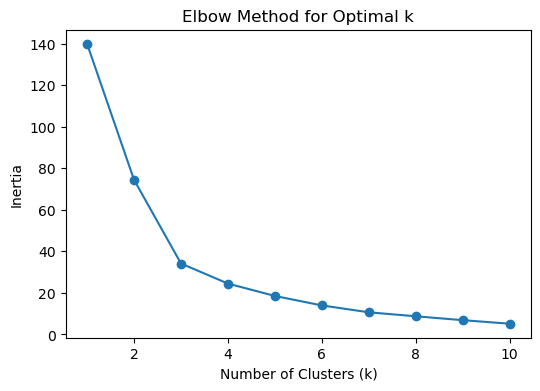

In [28]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select numeric features for clustering
features = [
    "Monthly_Growth_%",
    "AVG_Monthly_Sales",
    "CV",
    "Product_Revenue",
    "Contribution_%"
]

X = cluster_all[features]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, max_iter=300, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(6,4))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

The optimal number of clusters was determined using the Elbow Method, which evaluates the within-cluster sum of squares (inertia) for different values of k. As shown in the plot, inertia decreases rapidly between k = 1 and k = 3, indicating that adding clusters significantly improves the model. However, after k = 4, the decrease in inertia becomes much smaller and the curve starts to flatten. This indicates diminishing returns from adding more clusters. Therefore, k = 4 was selected as the optimal number of clusters, as it provides a good balance between model complexity and explanatory power.

### 4.2. K-Mean Clustering Method 

In [29]:
# KMeans pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

kmeans_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=4, init="k-means++", n_init=10, max_iter=300, random_state=42))
])

# Fit the pipeline
kmeans_pipeline.fit(X)

# Get cluster labels
cluster_all["Cluster"] = kmeans_pipeline.named_steps["kmeans"].labels_


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [30]:
cluster_summary = cluster_all.groupby("Cluster")[features].mean()
print(cluster_summary)

         Monthly_Growth_%  AVG_Monthly_Sales        CV  Product_Revenue  \
Cluster                                                                   
0                0.491501         147.401204  0.163265     10318.084250   
1               -0.639621        1574.495918  0.107619    110214.714286   
2                9.331856          49.386255  0.433151      3457.037881   
3                4.722300         520.258025  0.366016     36418.061717   

         Contribution_%  
Cluster                  
0             20.109938  
1             63.817585  
2             13.570144  
3             92.133837  


K-Mean Clustering for country

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

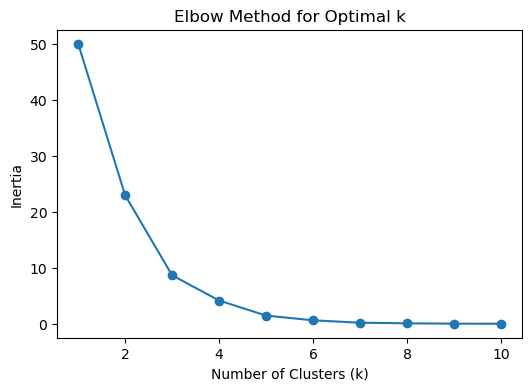

         Country  Monthly_Growth_%  AVG_Monthly_Sales        CV  \
0        Albania         -0.653208        1130.053922  0.108180   
1  Arab Emirates         -0.244124         349.954896  0.145525   
2         Bosnia         -0.889655        1950.787119  0.092970   
3        Belgium          1.321750        1054.244277  0.273588   
4        Bahamas         -0.222917        2121.917661  0.120150   
5         Cyprus         -0.613608         466.707944  0.118495   
6        Hungary          7.177251         152.128915  0.412155   
7          Spain         -0.326957         407.300000  0.122247   
8          Japan         -0.858091        3192.657143  0.100884   
9    Netherlands         -0.889712        3840.828571  0.097587   

   Product_Revenue  Contribution_%  Cluster  
0     79103.774568        7.704958        1  
1     24496.842748        2.386070        1  
2    136555.098331       13.300899        3  
3     73797.099379        7.188071        1  
4    148534.236268       14.4677

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [31]:

X = cluster_all_c[features]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, max_iter=300, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(6,4))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

kmeans_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=4, init="k-means++", n_init=10, max_iter=300, random_state=42))
])

# Fit the pipeline
kmeans_pipeline.fit(X)

# Get cluster labels
cluster_all_c["Cluster"] = kmeans_pipeline.named_steps["kmeans"].labels_

print(cluster_all_c)

cluster_summary_c = cluster_all_c.groupby("Cluster")[features].mean()
print(cluster_summary_c)

## 5. Results to xlsx

In [32]:
cluster_all.to_excel("cluster_all.xlsx", index=False)
cluster_all_c.to_excel("cluster_all_c.xlsx", index=False)